In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.ndimage import uniform_filter1d

In [2]:
# Custom KDE calculations, since we know the standard deviations
class KDE:
    def __init__(self, filtered_df, x_min=0, x_max=70000, x_points=7000):
        self.medians = {
            "c30_raw": filtered_df["raw_median"].xs("ctrl_30", level=1).to_numpy(),
            "c300_raw": filtered_df["raw_median"].xs("ctrl_300", level=1).to_numpy(),
            "uv30_raw": filtered_df["raw_median"].xs("uv_30", level=1).to_numpy(),
            "uv300_raw": filtered_df["raw_median"].xs("uv_300", level=1).to_numpy(),
            "c30_norm": filtered_df["norm_median"].xs("ctrl_30", level=1).to_numpy(),
            "c300_norm": filtered_df["norm_median"].xs("ctrl_300", level=1).to_numpy(),
            "uv30_norm": filtered_df["norm_median"].xs("uv_30", level=1).to_numpy(),
            "uv300_norm": filtered_df["norm_median"].xs("uv_300", level=1).to_numpy()
        }
        self.stds = {
            "c30_raw": filtered_df["raw_std"].xs("ctrl_30", level=1).to_numpy(),
            "c300_raw": filtered_df["raw_std"].xs("ctrl_300", level=1).to_numpy(),
            "uv30_raw": filtered_df["raw_std"].xs("uv_30", level=1).to_numpy(),
            "uv300_raw": filtered_df["raw_std"].xs("uv_300", level=1).to_numpy(),
            "c30_norm": filtered_df["norm_std"].xs("ctrl_30", level=1).to_numpy(),
            "c300_norm": filtered_df["norm_std"].xs("ctrl_300", level=1).to_numpy(),
            "uv30_norm": filtered_df["norm_std"].xs("uv_30", level=1).to_numpy(),
            "uv300_norm": filtered_df["norm_std"].xs("uv_300", level=1).to_numpy()
        }
        self.x_list = np.linspace(x_min, x_max, x_points)
        self.kde = self.solve_kdes()
        
    def solve_gaussian(self, val, data_array, sigma_array):
        return (1. / sigma_array) * np.exp(- (val - data_array) * (val - data_array) / (2 * sigma_array * sigma_array))

    def solve_kdes(self):
        kdes = {}
        for key, med_array in self.medians.items():
            kde_array = np.zeros((len(med_array), len(self.x_list)))
            for i, xx in enumerate(self.x_list):
                single_kde = self.solve_gaussian(xx, med_array, self.stds[key])
                kde_array[:, i] = np.array(single_kde)

            vector = np.sum(kde_array, axis=0)
            kdes[key] = vector / np.trapezoid(vector)
        
        return kdes

def moving_average(a, n=1):
    if n == 1:
        return a
    return uniform_filter1d(a, n)[n//2 : -(n//2)]
    

# READ IN DATA

In [ ]:
# Multiindex version
all_stats = pd.read_csv("data/tfam_array_all_stats.csv", index_col=[0,1], skipinitialspace=True, low_memory=False)
all_stats = all_stats.replace([np.inf, -np.inf], np.nan)
all_stats.head()

raw_mean  raw_median      raw_std  raw_std_percent  \
name        condition                                                       
ATP6_100_o1 ctrl_30      6678.1      6090.5  1143.436385        18.774097   
            uv_30       20787.1     22154.0  4584.957711        20.695846   
            ctrl_300     8862.1      9808.0  2534.278265        25.838889   
            uv_300      34395.6     34876.0  2345.630273         6.725629   
ATP6_100_o2 ctrl_30     11523.3     11679.0  1288.036840        11.028657   

                           raw_sem  raw_sem_percent  raw_variance_coefficient  \
name        condition                                                           
ATP6_100_o1 ctrl_30     361.586334         5.936891                  0.171222   
            uv_30      1449.890934         6.544601                  0.220567   
            ctrl_300    801.409154         8.170974                  0.285968   
            uv_300      741.753421         2.126831                  0.068196   
ATP6_100_o2 ctrl_30     407.313012         3.487568                  0.111777   

                       raw_mean_z  raw_median_z     norm_mean  ...  \
name        condition                                          ...   
ATP6_100_o1 ctrl_30      4.173026      3.906550   6450.989200  ...   
            uv_30        0.136003      0.225967  20328.020609  ...   
            ctrl_300     4.390684      4.642301   8098.237680  ...   
            uv_300       2.174850      2.289422  33988.129304  ...   
ATP6_100_o2 ctrl_30     13.522224     13.323943  11510.808570  ...   

                                                                sequence  \
name        condition                                                      
ATP6_100_o1 ctrl_30    ACACTAAAGGACGAACCTGATCTCTTATACTAGCATATGCGTGCGT...   
            uv_30      ACACTAAAGGACGAACCTGATCTCTTATACTAGCATATGCGTGCGT...   
            ctrl_300   ACACTAAAGGACGAACCTGATCTCTTATACTAGCATATGCGTGCGT...   
            uv_300     ACACTAAAGGACGAACCTGATCTCTTATACTAGCATATGCGTGCGT...   
ATP6_100_o2 ctrl_30    CTAGTATAAGAGATCAGGTTCGTCCTTTAGTGTCATATGCGTGCGT...   

                       start_coord  end_coord  mid_coord  tt  tc  ct  cc  \
name        condition                                                      
ATP6_100_o1 ctrl_30         8711.0     8743.0     8727.0   4   5   7   3   
            uv_30           8711.0     8743.0     8727.0   4   5   7   3   
            ctrl_300        8711.0     8743.0     8727.0   4   5   7   3   
            uv_300          8711.0     8743.0     8727.0   4   5   7   3   
ATP6_100_o2 ctrl_30         8711.0     8743.0     8727.0   4   6   7   3   

                          at     gc  
name        condition                
ATP6_100_o1 ctrl_30    58.82  41.18  
            uv_30      58.82  41.18  
            ctrl_300   58.82  41.18  
            uv_300     58.82  41.18  
ATP6_100_o2 ctrl_30    58.82  41.18  

[5 rows x 29 columns]

In [4]:
# Single index for easy plotting with Seaborn
a = pd.read_csv("data/tfam_array_all_stats.csv", low_memory=False)
a = a.dropna(subset="name", ignore_index=True).replace([np.inf, -np.inf], np.nan) # Remove blanks
a.head()

,name,condition,raw_mean,raw_median,raw_std,raw_std_percent,raw_sem,raw_sem_percent,raw_variance_coefficient,raw_mean_z,...,mid_coord,tt,tc,ct,cc,at,gc,g10g_count,g10g_start,g10g
0,ATP6_100_o1,ctrl_30,6678.1,6090.5,1143.436385,18.774097,361.586334,5.936891,0.171222,4.173026,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
1,ATP6_100_o1,uv_30,20787.1,22154.0,4584.957711,20.695846,1449.890934,6.544601,0.220567,0.136003,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
2,ATP6_100_o1,ctrl_300,8862.1,9808.0,2534.278265,25.838889,801.409154,8.170974,0.285968,4.390684,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
3,ATP6_100_o1,uv_300,34395.6,34876.0,2345.630273,6.725629,741.753421,2.126831,0.068196,2.174850,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
4,ATP6_100_o2,ctrl_30,11523.3,11679.0,1288.036840,11.028657,407.313012,3.487568,0.111777,13.522224,...,8727.0,4,6,7,3,58.82,41.18,2,29,True


# Median distributions

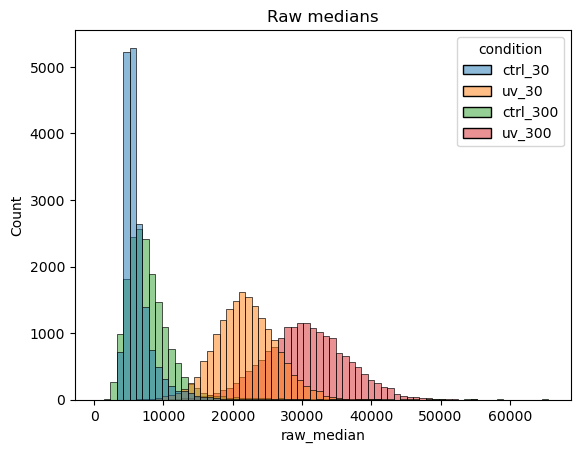

In [5]:
g = sns.histplot(data=all_stats, x="raw_median", hue="condition")
g.set(title="Raw medians")
plt.show()

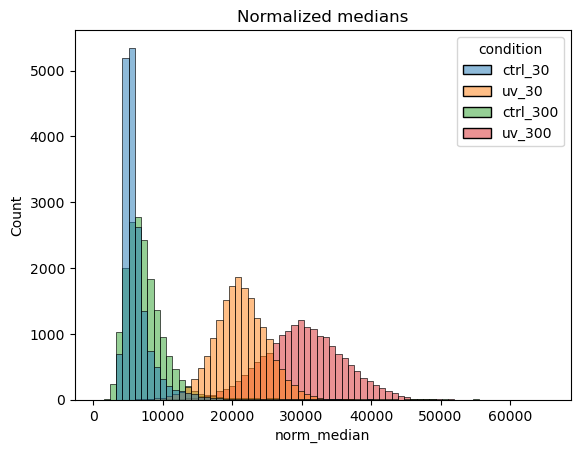

In [6]:
g = sns.histplot(data=all_stats, x="norm_median", hue="condition")
g.set(title="Normalized medians")
plt.show()

# Controls

In [7]:
all_stats.loc[
    ["control" in str(i[0]).lower() for i in all_stats.index],
    [("median" in c) or ("std" in c) for c in all_stats.columns]
]

raw_median      raw_std  raw_std_percent  \
name              condition                                             
NegativeControl   ctrl_30        5972.5  2190.462269        36.675802   
                  uv_30          9271.0  1474.130770        15.900451   
                  ctrl_300       9014.0  2630.190414        29.178948   
                  uv_300        15262.5  1104.495163         7.236660   
primer_control    ctrl_30       21584.0  7888.395703        36.547423   
                  uv_30         19339.5  3731.475014        19.294579   
                  ctrl_300      23710.0  7411.581774        31.259307   
                  uv_300        17577.5  1204.457923         6.852271   
primer_control_ss ctrl_30       16182.5  3007.490175        18.584830   
                  uv_30         14453.0  2180.354326        15.085825   
                  ctrl_300      26830.5  8430.650457        31.421891   
                  uv_300        24544.0  1646.105333         6.706752   

                             raw_median_z   norm_median     norm_std  \
name              condition                                            
NegativeControl   ctrl_30        3.327766   5993.531351  2148.160403   
                  uv_30         -3.849785   9276.007383   837.312876   
                  ctrl_300       4.507322   8218.785146  1091.928411   
                  uv_300        -2.450893  15073.135047   968.209251   
primer_control    ctrl_30       31.643218  21317.956063  5789.432342   
                  uv_30         -0.546337  18435.990690  1091.076766   
                  ctrl_300      19.007445  23204.814460  2812.680080   
                  uv_300        -1.703436  18129.538196   682.260006   
primer_control_ss ctrl_30       21.357684  15751.387602  1866.329344   
                  uv_30         -2.194282  13866.478868  1132.461016   
                  ctrl_300      23.084198  27418.180661  3637.619336   
                  uv_300        -0.373982  23565.772415  1073.236343   

                             norm_std_percent  norm_median_z  
name              condition                                   
NegativeControl   ctrl_30           35.841314      -0.106818  
                  uv_30              9.026652      -3.081269  
                  ctrl_300          13.285764       0.118713  
                  uv_300             6.423410      -2.592985  
primer_control    ctrl_30           27.157540       5.397161  
                  uv_30              5.918189      -0.730308  
                  ctrl_300          12.121106       3.745126  
                  uv_300             3.763251      -2.072104  
primer_control_ss ctrl_30           11.848666       3.397851  
                  uv_30              8.166897      -1.903099  
                  ctrl_300          13.267180       4.764703  
                  uv_300             4.554217      -1.145645

# Universal binders

In [8]:
# Get KDEs
bottom_ub_kde = KDE(filtered_df=all_stats[[("universal_bottom" in str(i[0]).lower()) and ("_ss" not in str(i[0]).lower()) for i in all_stats.index]])
top_ub_kde = KDE(filtered_df=all_stats[[("universal_top" in str(i[0]).lower()) and ("_ss" not in str(i[0]).lower()) for i in all_stats.index]])

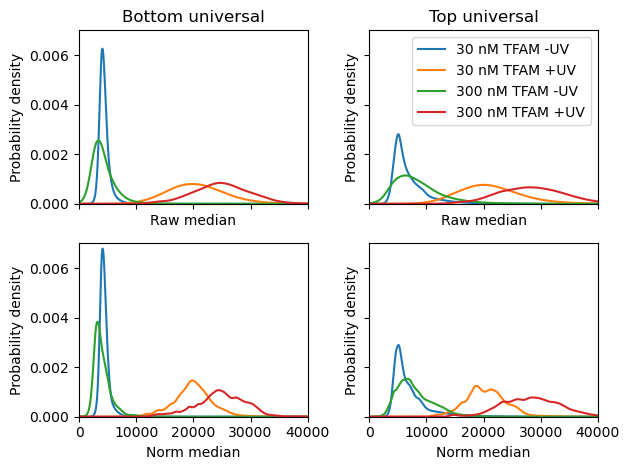

In [9]:
# Raw universal binders
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs[0, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["c30_raw"], label="30 nM TFAM -UV")
axs[0, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["uv30_raw"], label="30 nM TFAM +UV")
axs[0, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["c300_raw"], label="300 nM TFAM -UV")
axs[0, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["uv300_raw"], label="300 nM TFAM +UV")

axs[0, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["c30_raw"], label="30 nM TFAM -UV")
axs[0, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["uv30_raw"], label="30 nM TFAM +UV")
axs[0, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["c300_raw"], label="300 nM TFAM -UV")
axs[0, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["uv300_raw"], label="300 nM TFAM +UV")

axs[1, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["c30_norm"], label="30 nM TFAM -UV")
axs[1, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["uv30_norm"], label="30 nM TFAM +UV")
axs[1, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["c300_norm"], label="300 nM TFAM -UV")
axs[1, 0].plot(bottom_ub_kde.x_list, bottom_ub_kde.kde["uv300_norm"], label="300 nM TFAM +UV")

axs[1, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["c30_norm"], label="30 nM TFAM -UV")
axs[1, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["uv30_norm"], label="30 nM TFAM +UV")
axs[1, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["c300_norm"], label="300 nM TFAM -UV")
axs[1, 1].plot(top_ub_kde.x_list, top_ub_kde.kde["uv300_norm"], label="300 nM TFAM +UV")

axs[0, 0].set(xlim=(0, 40000), ylim=(0, 0.007), title="Bottom universal", ylabel="Probability density", xlabel="Raw median")
axs[0, 1].set(xlim=(0, 40000), ylim=(0, 0.007), title="Top universal", ylabel="Probability density", xlabel="Raw median")
axs[1, 0].set(xlim=(0, 40000), ylim=(0, 0.007), ylabel="Probability density", xlabel="Norm median")
axs[1, 1].set(xlim=(0, 40000), ylim=(0, 0.007), ylabel="Probability density", xlabel="Norm median")
axs[0, 1].legend()
#ax2.legend()
plt.tight_layout()

# Binding profile across mito genome
If it binds specifically, we would expect multiple probes to be intense back to back

In [10]:
# Get all sequences with a valid start coord (1-indexed) and remove extra sequences around inserted fasta nucleotide
genome = all_stats[all_stats["start_coord"] > 0].copy(deep=True)
genome = genome[[(not str(i[0]).lower().endswith("_a")) and (not str(i[0]).lower().endswith("_g")) and (not str(i[0]).lower().endswith("_t")) for i in genome.index]]

# Add gene names
genes = [str(i[0]).split("_")[0] for i in genome.index]
genome["gene"] = genes

# Split the forward/reverse orientations
f_genome = genome[["_o1" in str(i[0]) for i in genome.index]]
r_genome = genome[["_o2" in str(i[0]) for i in genome.index]]
f_genome.head()

raw_mean  raw_median      raw_std  raw_std_percent  \
name        condition                                                       
ATP6_100_o1 ctrl_30      6678.1      6090.5  1143.436385        18.774097   
            uv_30       20787.1     22154.0  4584.957711        20.695846   
            ctrl_300     8862.1      9808.0  2534.278265        25.838889   
            uv_300      34395.6     34876.0  2345.630273         6.725629   
ATP6_101_o1 ctrl_30      6716.7      6860.0  1473.154970        21.474562   

                           raw_sem  raw_sem_percent  raw_variance_coefficient  \
name        condition                                                           
ATP6_100_o1 ctrl_30     361.586334         5.936891                  0.171222   
            uv_30      1449.890934         6.544601                  0.220567   
            ctrl_300    801.409154         8.170974                  0.285968   
            uv_300      741.753421         2.126831                  0.068196   
ATP6_101_o1 ctrl_30     465.852505         6.790853                  0.219327   

                       raw_mean_z  raw_median_z     norm_mean  ...  \
name        condition                                          ...   
ATP6_100_o1 ctrl_30      4.173026      3.906550   6450.989200  ...   
            uv_30        0.136003      0.225967  20328.020609  ...   
            ctrl_300     4.390684      4.642301   8098.237680  ...   
            uv_300       2.174850      2.289422  33988.129304  ...   
ATP6_101_o1 ctrl_30      4.504655      4.143215   6630.467861  ...   

                       start_coord  end_coord  mid_coord  tt  tc  ct  cc  \
name        condition                                                      
ATP6_100_o1 ctrl_30         8711.0     8743.0     8727.0   4   5   7   3   
            uv_30           8711.0     8743.0     8727.0   4   5   7   3   
            ctrl_300        8711.0     8743.0     8727.0   4   5   7   3   
            uv_300          8711.0     8743.0     8727.0   4   5   7   3   
ATP6_101_o1 ctrl_30         8713.0     8745.0     8729.0   4   5   7   3   

                          at     gc  gene  
name        condition                      
ATP6_100_o1 ctrl_30    58.82  41.18  ATP6  
            uv_30      58.82  41.18  ATP6  
            ctrl_300   58.82  41.18  ATP6  
            uv_300     58.82  41.18  ATP6  
ATP6_101_o1 ctrl_30    61.76  38.24  ATP6  

[5 rows x 30 columns]

In [11]:
# Split the treatment conditions 
c30_f = f_genome.xs("ctrl_30", level=1).sort_values(by="mid_coord")
uv30_f = f_genome.xs("uv_30", level=1).sort_values(by="mid_coord")
c300_f = f_genome.xs("ctrl_300", level=1).sort_values(by="mid_coord")
uv300_f = f_genome.xs("uv_300", level=1).sort_values(by="mid_coord")

c30_r = r_genome.xs("ctrl_30", level=1).sort_values(by="mid_coord")
uv30_r = r_genome.xs("uv_30", level=1).sort_values(by="mid_coord")
c300_r = r_genome.xs("ctrl_300", level=1).sort_values(by="mid_coord")
uv300_r = r_genome.xs("uv_300", level=1).sort_values(by="mid_coord")

c30_f.head()

,raw_mean,raw_median,raw_std,raw_std_percent,raw_sem,raw_sem_percent,raw_variance_coefficient,raw_mean_z,raw_median_z,norm_mean,...,start_coord,end_coord,mid_coord,tt,tc,ct,cc,at,gc,gene
name,,,,,,,,,,,,,,,,,,,,,
D-loop_554_o1,4739.5,4806.0,855.244117,17.795342,270.451937,5.627381,0.180450,0.889854,0.606488,4674.124608,...,16555.0,18.0,2.0,1,7,3,5,52.94,47.06,D-loop
D-loop_555_o1,4600.5,4596.5,467.995311,10.181558,147.993112,3.219691,0.101727,1.008136,1.050436,4738.139183,...,16557.0,20.0,4.0,0,8,4,5,50.00,50.00,D-loop
D-loop_556_o1,4653.5,4699.0,757.054416,16.110969,239.401627,5.094736,0.162685,0.858936,0.801007,4657.391863,...,16559.0,22.0,6.0,0,7,3,5,52.94,47.06,D-loop
D-loop_557_o1,5184.7,5281.5,563.776364,10.674550,178.281740,3.375589,0.108738,1.875717,1.735524,5207.676959,...,16561.0,24.0,8.0,1,6,3,5,55.88,44.12,D-loop
D-loop_558_o1,4460.9,4353.0,442.972146,10.176250,140.080092,3.218013,0.099301,0.588126,0.579729,4510.828188,...,16563.0,26.0,10.0,2,5,3,6,52.94,47.06,D-loop


# z score distributions

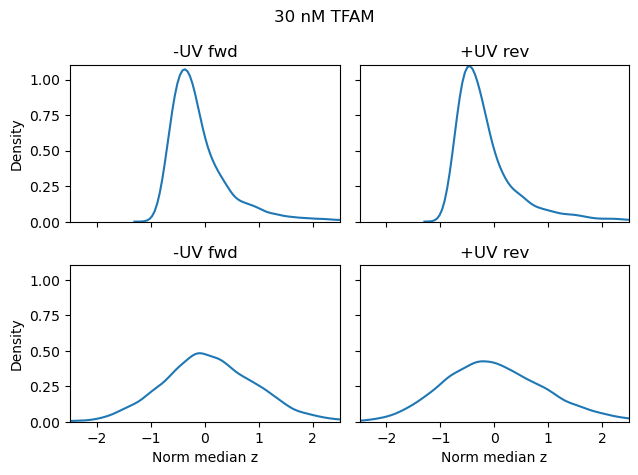

In [12]:
# 30 nM z distributions
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
sns.kdeplot(ax=axs[0,0], data=c30_f, x="norm_median_z")
sns.kdeplot(ax=axs[0,1], data=c30_r, x="norm_median_z")
sns.kdeplot(ax=axs[1,0], data=uv30_f, x="norm_median_z")
sns.kdeplot(ax=axs[1,1], data=uv30_r, x="norm_median_z")
axs[0,0].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="-UV fwd")
axs[1,0].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="-UV fwd")
axs[0,1].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="+UV rev")
axs[1,1].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="+UV rev")
plt.suptitle("30 nM TFAM")
plt.tight_layout()
plt.show()

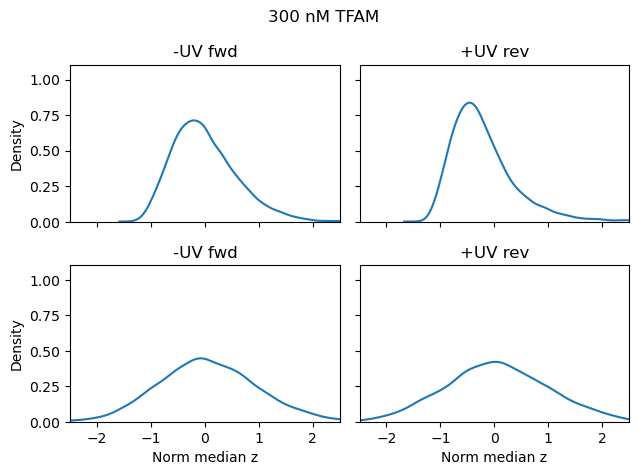

In [13]:
# 30 nM z distributions
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
sns.kdeplot(ax=axs[0,0], data=c300_f, x="norm_median_z")
sns.kdeplot(ax=axs[0,1], data=c300_r, x="norm_median_z")
sns.kdeplot(ax=axs[1,0], data=uv300_f, x="norm_median_z")
sns.kdeplot(ax=axs[1,1], data=uv300_r, x="norm_median_z")
axs[0,0].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="-UV fwd")
axs[1,0].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="-UV fwd")
axs[0,1].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="+UV rev")
axs[1,1].set(xlim=(-2.5, 2.5), ylim=(0, 1.1), xlabel="Norm median z", ylabel="Density", title="+UV rev")
plt.suptitle("300 nM TFAM")
plt.tight_layout()
plt.show()

# "Sun" plots
- Figure 3 (main)
- Figure 3 figure supplement 3

In [14]:
def max_z_plot_separated(
    co1: pd.DataFrame,
    co2: pd.DataFrame,
    uvo1: pd.DataFrame,
    uvo2: pd.DataFrame,
    tfam_concentration: str,
    window: int = 1,
    offset: int | float = 2,
    save_figure: bool = False
):
    """
    Generates two circular polar plots (-UV top, +UV bottom) of normalized median z-scores with TFAM binding regions highlighted.

    Takes forward and reverse strand data for control and UV conditions, computes the element-wise maximum z-score between strands, and plots the UV signal as a filled polar trace over the mitochondrial genome (16,569 bp). Known LSP/HSP promoter binding regions and additional high/low regions are overlaid in yellow. Background bands indicate z-score magnitude (blue for positive, pink for negative).

    Parameters
    ----------
    co1 : pandas.DataFrame
        Control condition, forward strand. Must contain 'mid_coord' and 'norm_median_z' columns.
    co2 : pandas.DataFrame
        Control condition, reverse strand. Same required columns as co1.
    uvo1 : pandas.DataFrame
        UV condition, forward strand. Same required columns as co1.
    uvo2 : pandas.DataFrame
        UV condition, reverse strand. Same required columns as co1.
    tfam_concentration : str
        Label for the TFAM concentration, used in the output filename (e.g., '30_nM').
    window : int, optional
        Window size for the moving average smoothing of coordinates and max z-scores. Default is 1 (no smoothing).
    offset : int or float, optional
        Radial offset that sets the baseline (zero-line) on the polar plot. Default is 2.
    save_figure : bool, optional
        Save the figure as both PNG and SVG. Default is False.

    Returns
    -------
    None
        Displays the plot and prints the y-axis (radial) limits.
    """
    
    fig, ax = plt.subplots(2, 1, subplot_kw={'projection': 'polar'}, figsize=(20,40))
    
    cxf = moving_average(co1["mid_coord"].to_numpy(), n=window) 
    cyf = co1["norm_median_z"].to_numpy()

    cxr = moving_average(co2["mid_coord"].to_numpy(), n=window)
    cyr = co2["norm_median_z"].to_numpy()
    
    cmaxy = [max((f, r)) + offset for f, r in zip(cyf, cyr)]
    cmaxy = moving_average(cmaxy, n=window)
    
    uvxf = moving_average(uvo1["mid_coord"].to_numpy(), n=window) 
    uvyf = uvo1["norm_median_z"].to_numpy()

    uvxr = moving_average(uvo2["mid_coord"].to_numpy(), n=window)
    uvyr = uvo2["norm_median_z"].to_numpy()
    
    uvmaxy = [max((f, r)) + offset for f, r in zip(uvyf, uvyr)]
    uvmaxy = moving_average(uvmaxy, n=window)

    pos_colors = {
        "low": "#9BCEFD",
        "mid": "#C3E2FD",
        "high": "#ECF5FE"
    }

    neg_colors = {
        "low": "#DF6883",
        "mid": "#EA9AAD",
        "high": "#F4CDD6"
    }

    x_scale = 16569 # len(c30_f["mid_coord"].to_numpy())
    thetaf = 2 * np.pi * (cxf / x_scale)
    y_lim_min = min((min(cmaxy), min(uvmaxy)))
    y_lim_max = max((max(cmaxy), max(uvmaxy)))
    
    for i, y, label, col in [(0, cmaxy, "- UV", "#416788"), (1, uvmaxy, "+ UV", "#519071")]:
        ax[i].plot(thetaf, [offset] * len(thetaf), linestyle="--", color="black")

        ax[i].fill_between(thetaf, offset, offset + 1, linestyle="--", color=pos_colors["low"], alpha=0.4)
        ax[i].fill_between(thetaf, offset + 1, offset + 2, linestyle="--", color=pos_colors["mid"], alpha=0.4)
        ax[i].fill_between(thetaf, offset + 2, offset + 3, linestyle="--", color=pos_colors["high"], alpha=0.4)
        ax[i].fill_between(thetaf, offset, offset - 1, linestyle="--", color=neg_colors["high"], alpha=0.4)

        # plotting the polar coordinates on the system
        lhsp_bind_starts = np.array([422, 16044, 521, 629, 3965, 11665]) # lsp1, lsp2, hsp1, hsp2, high region (3985), low region (11685)
        lhsp_bind_ends = np.array([447, 16069, 546, 636, 4045, 11745]) # lsp1, lsp2, hsp1, hsp2, high region (4023), low region (11723)
        lhsp_starts = np.array([390, 16013, 561, 644, 3965, 11665]) # lsp1, lsp2, hsp1, hsp2, high region (3985), low region (11685)
        lhsp_ends = np.array([408, 16029, 577, 651, 4045, 11745]) # lsp1, lsp2, hsp1, hsp2, high region (4023), low region (11723)

        ymin = -1
        ymax = 3

        for quad in zip(lhsp_bind_starts, lhsp_bind_ends, lhsp_starts, lhsp_ends):
            start = min(quad)
            start_theta = start // 2
            end = max(quad)
            end_theta = end // 2
            ax[i].fill_between(thetaf[start_theta:end_theta+1], ymin, ymax, color="#FFC704", alpha=0.4)

        ax[i].fill_between(thetaf, y, label=label, color=col, alpha=0.5, linewidth=0)
        ax[i].plot(thetaf, y, color=col, linewidth=3)

        fig_file = f"rolling_windows/{tfam_concentration}_{window}nt"
        # print(y_lim_min, y_lim_max)

        ax[i].set_rorigin(-10)
        ax[i].set_theta_zero_location("N")
        ax[i].grid(False)
        ax[i].set_theta_direction(-1)
        ax[i].set_ylim([y_lim_min, y_lim_max])
        ax[i].set_yticklabels([])
        ax[i].legend()
        ax[i].axis("off")
    
    plt.tight_layout()
    if save_figure:
        plt.savefig(fig_file + ".png")
        plt.savefig(fig_file + ".svg")
    plt.show()

### Figure 3 (main) - 30 nM TFAM Sun Plots, +/- UV

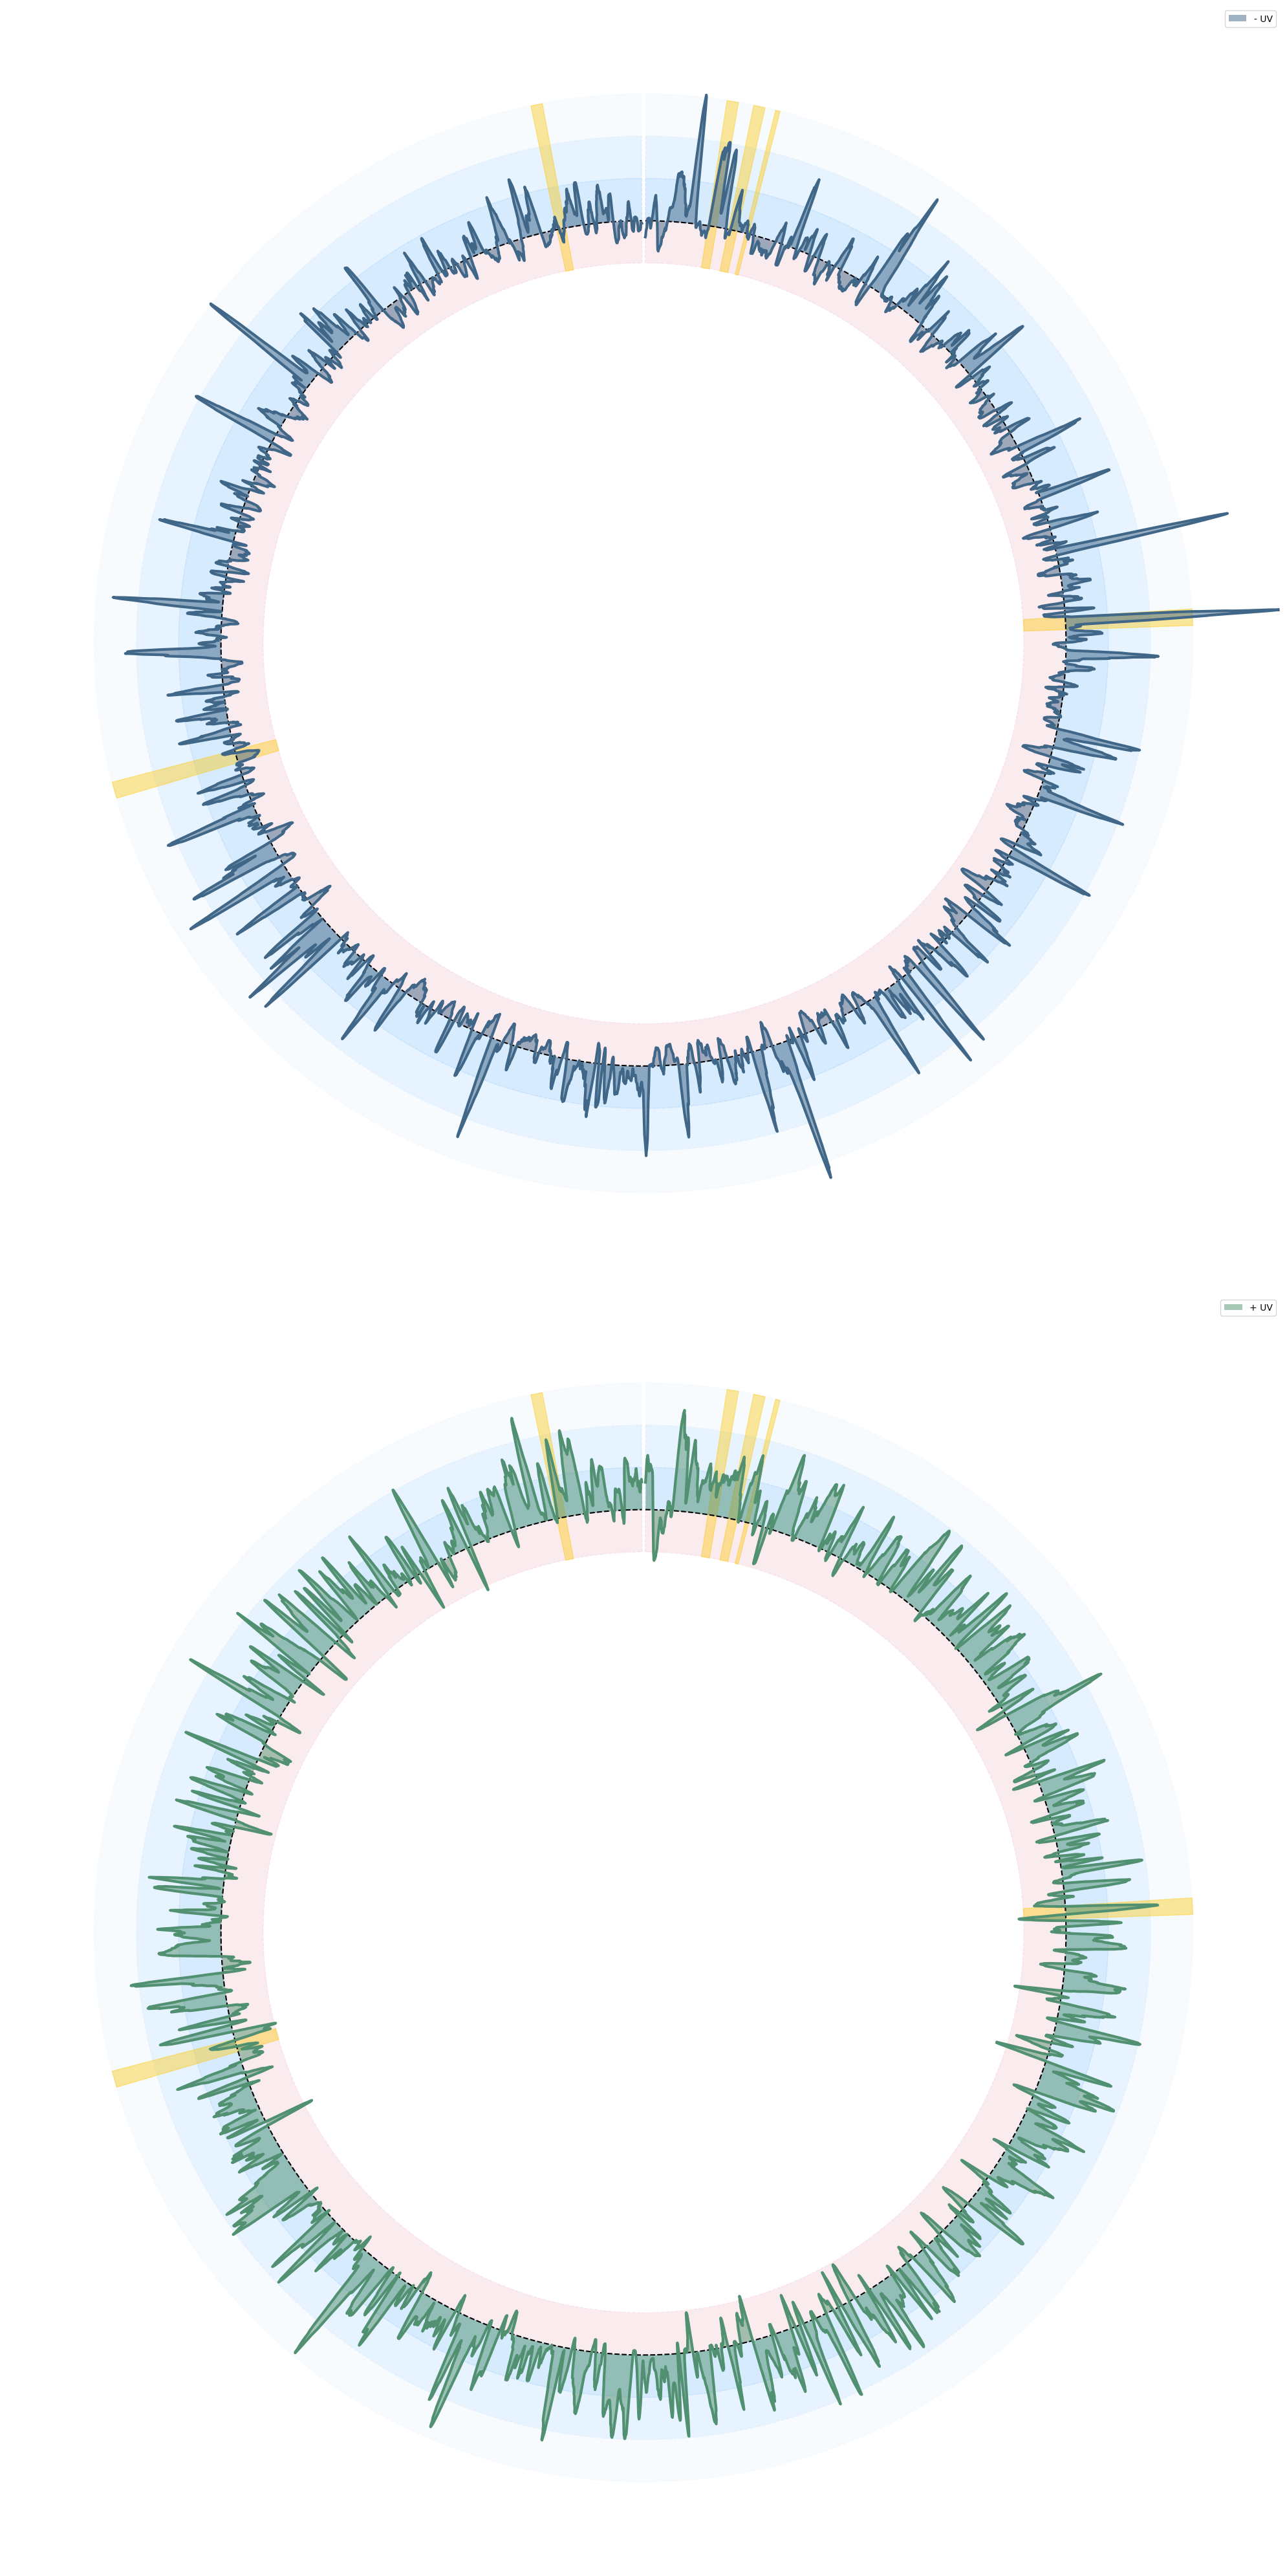

In [15]:
max_z_plot_separated(c30_f, c30_r, uv30_f, uv30_r, "30_nM", window=11, offset=0)

### Figure 3 figure supplement 3 - 300 nM TFAM Sun Plots, +/- UV

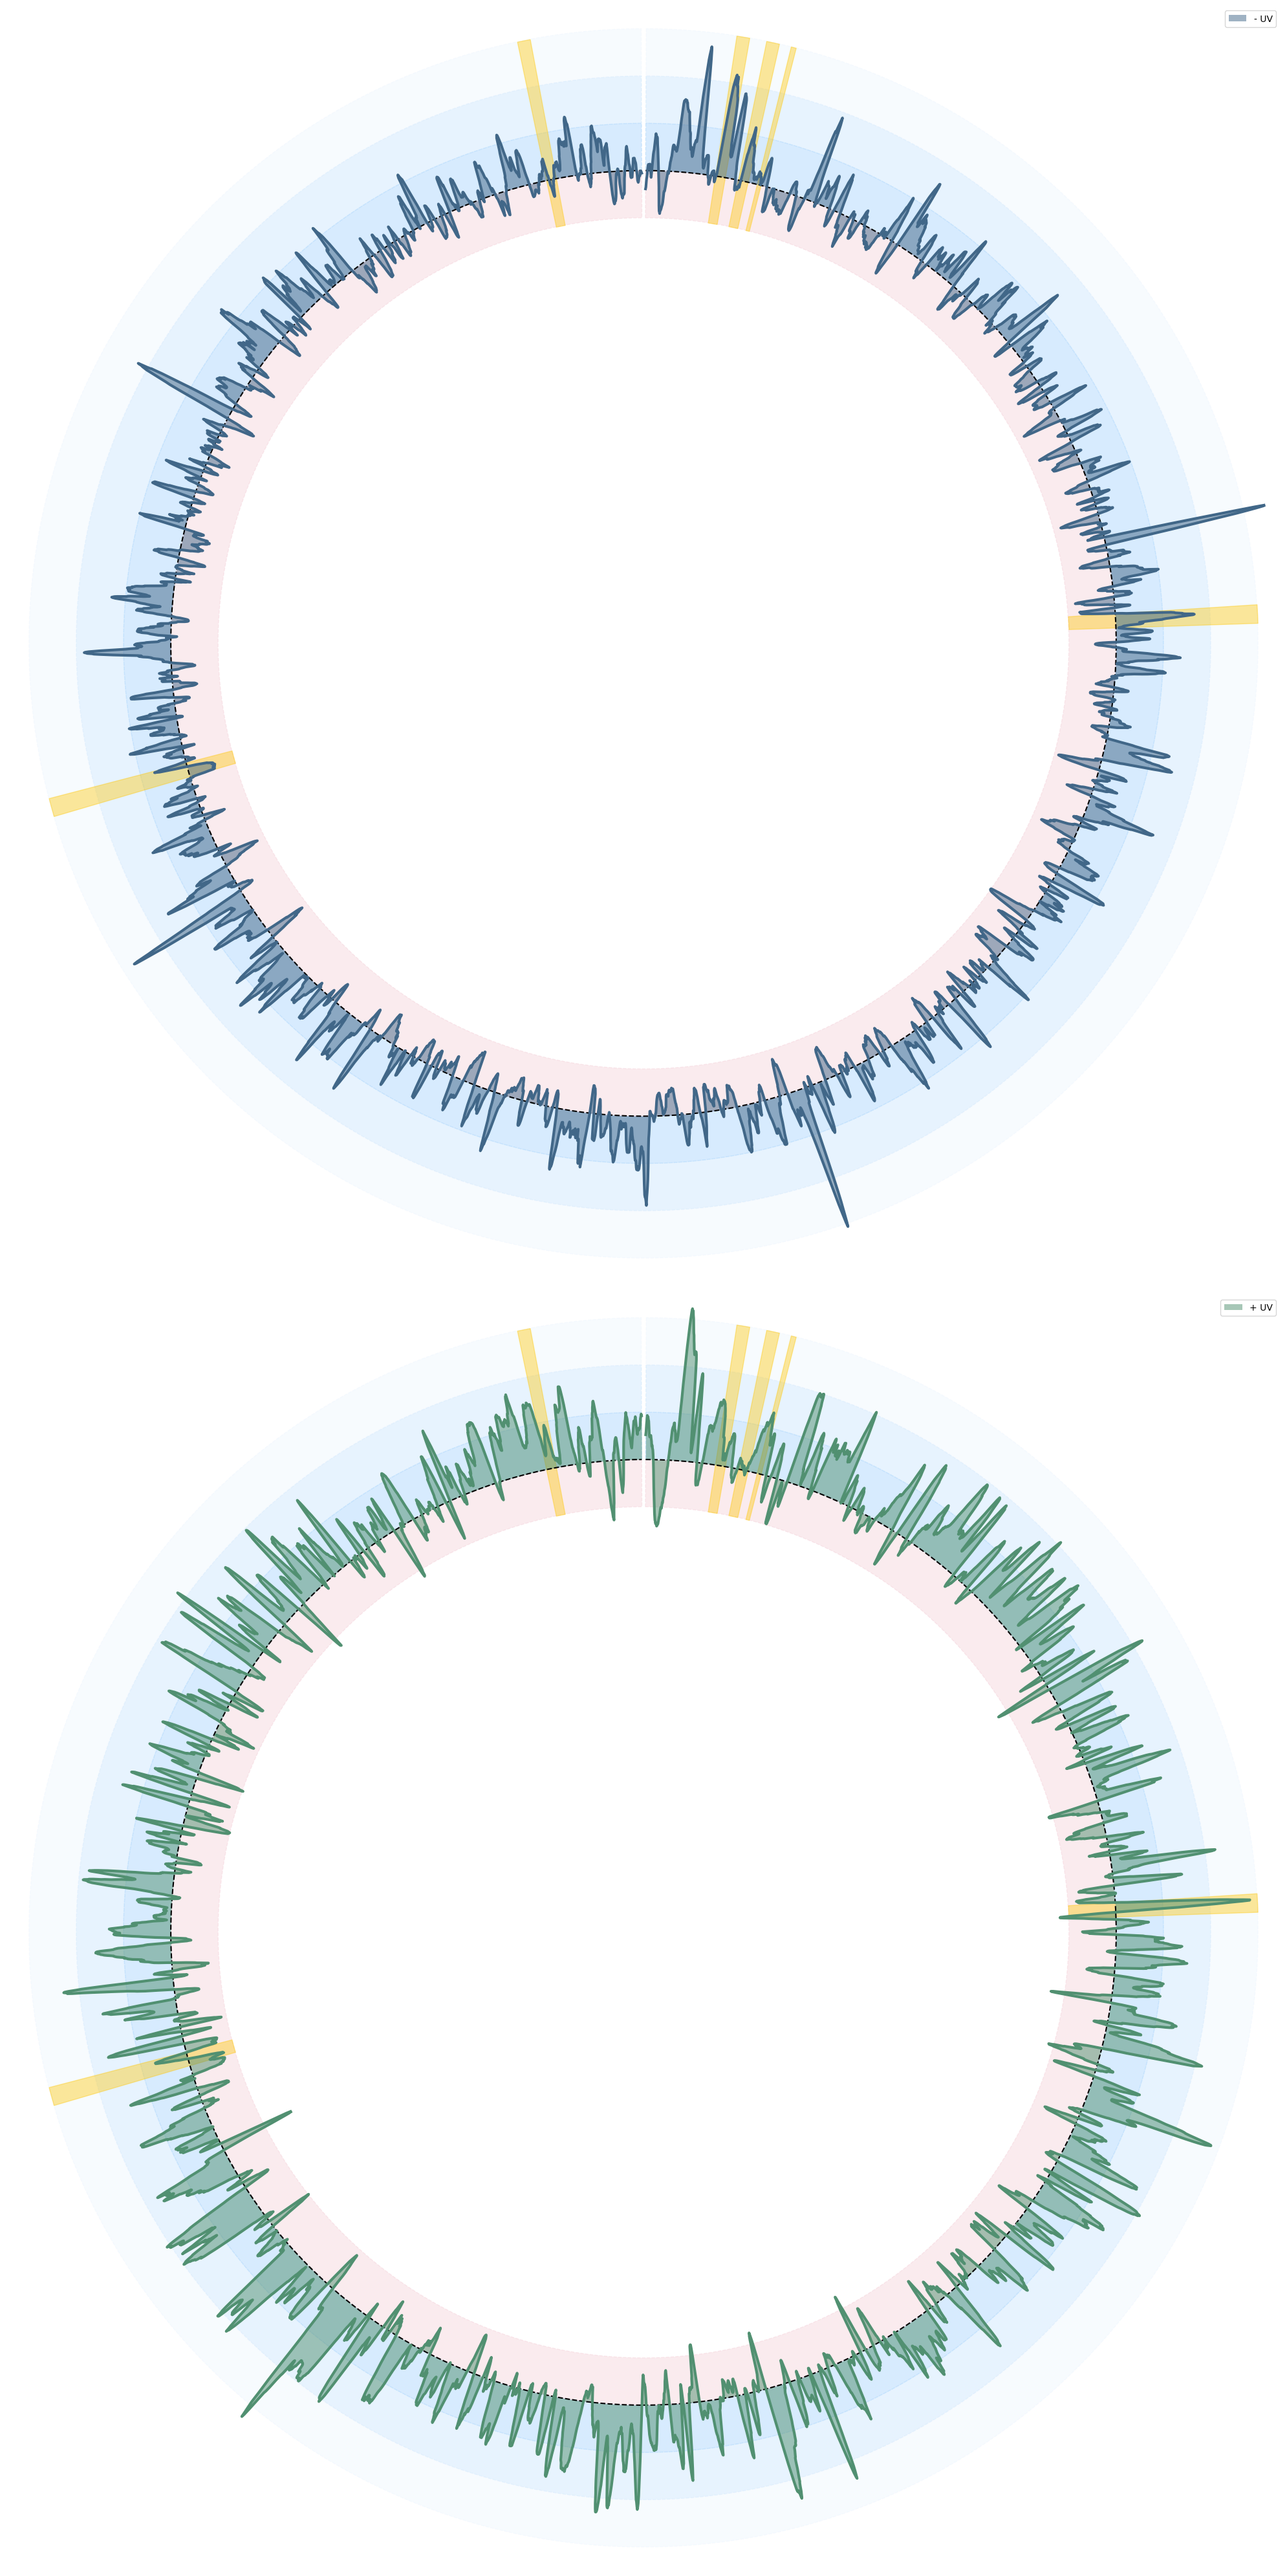

In [16]:
max_z_plot_separated(c300_f, c300_r, uv300_f, uv300_r, "300_nM", window=11, offset=0)

# High resolution binding site views
- Figure 3 figure supplement 8

In [17]:
# plot example regions in more detail
def breakout_sep(
    co1: pd.DataFrame,
    co2: pd.DataFrame,
    uvo1: pd.DataFrame,
    uvo2: pd.DataFrame,
    condition: str,
    mito_sequence: str,
    window: int = 1,
    total_length: int = 41,
    offset: int = 7,
    save_figure: bool = False
) -> None:
    """
    Plot detailed breakout views of TFAM binding regions on the mitochondrial genome.

    For each LSP/HSP binding site, generates a subplot showing control and UV
    z-score profiles (upper and lower panels separated by an offset) with the
    underlying nucleotide sequence displayed as color-coded letters. Binding
    footprint regions are highlighted in yellow and transcription start sites
    in purple.

    Parameters
    ----------
    co1 : pd.DataFrame
        Control condition, forward strand. Must contain 'mid_coord' and
        'norm_median_z' columns.
    co2 : pd.DataFrame
        Control condition, reverse strand. Same required columns as co1.
    uvo1 : pd.DataFrame
        UV condition, forward strand. Same required columns as co1.
    uvo2 : pd.DataFrame
        UV condition, reverse strand. Same required columns as co1.
    condition : str
        Label for the experimental condition, used in the output filename
        (e.g., '30_nM').
    mito_sequence : str
        Full mitochondrial reference genome sequence (16,569 bp). Genome
        coordinates in the data are 1-indexed; the string is accessed with
        a 0-indexed offset internally.
    window : int, optional
        Window size for moving average smoothing. Default is 1 (no smoothing).
    total_length : int, optional
        Number of genomic positions to display per subplot. The region is
        padded symmetrically around each binding site to reach this length.
        Default is 41.
    offset : int, optional
        Vertical gap between the lower (UV) and upper (control) plot panels
        within each subplot. Default is 7.
    save_figure : bool, optional
        If True, save the figure to 'rolling_windows/breakouts_same_direction.svg'.
        Default is False.

    Returns
    -------
    None
        Displays the figure and prints the coordinate range of each subplot.
    """

    # REGIONS OF INTEREST
    cxf = co1["mid_coord"].to_list()[window // 2:-window // 2]

    cyf = moving_average(co1["norm_median_z"].to_numpy(), n=window)
    cyr = moving_average(co2["norm_median_z"].to_numpy(), n=window)

    cmaxy = [max((f, r)) + offset for f, r in zip(cyf, cyr)]

    uvxf = uvo1["mid_coord"].to_numpy()[window // 2:-window // 2]

    uvyf = moving_average(uvo1["norm_median_z"].to_numpy(), n=window)
    uvyr = moving_average(uvo2["norm_median_z"].to_numpy(), n=window)

    uvmaxy = [max((f, r)) for f, r in zip(uvyf, uvyr)]

    binding_sites = ["lsp1", "lsp2", "hsp1", "hsp2"]
    lhsp_bind_starts = np.array([422, 16044, 521, 629]) # lsp1, lsp2, hsp1, hsp2
    lhsp_bind_ends = np.array([447, 16069, 546, 636]) # lsp1, lsp2, hsp1, hsp2
    lhsp_starts = np.array([390, 16013, 561, 644]) # lsp1, lsp2, hsp1, hsp2
    lhsp_ends = np.array([408, 16029, 577, 651]) # lsp1, lsp2, hsp1, hsp2
    #422, 447, 390, 408
    pos_colors = {
        "low": "#9BCEFD",
        "mid": "#C3E2FD",
        "high": "#ECF5FE"
    }

    pos_gradient = ["#318CE1","#509EE6","#6FAFEB","#8FC1F0"]#,"#AED2F4","#CDE4F9","#ECF5FE"]
    pos_gradient = ["#318CE1","#6FAFEB","#AED2F4","#ECF5FE"]

    neg_colors = {
        "low": "#DF6883",
        "mid": "#DA5876",
        "high": "#D74769"
    }

    nuc_colors = {"A": "#E8453C", "T": "#3C7FC0", "G": "#F5B222", "C": "#48A84E"}

    fig, axs = plt.subplots(len(lhsp_bind_starts), 1, figsize=(8,30))
    for i, quad in enumerate(zip(lhsp_bind_starts, lhsp_bind_ends, lhsp_starts, lhsp_ends)):
        start = min(quad)
        start_ind = cxf.index(start) if start in cxf else cxf.index(start - 1)

        end = max(quad)
        end_ind = cxf.index(end) if end in cxf else cxf.index(end + 1)

        buffer = total_length - len(cxf[start_ind:end_ind + 1])
        if i == 0:
            front_buffer = 2
        else:
            front_buffer = buffer // 2
        back_buffer = buffer - front_buffer

        cx = cxf[start_ind - front_buffer:end_ind + back_buffer + 1]
        #print(cx[0], cx[-1], len(cx))
        uvx = uvxf[start_ind - front_buffer:end_ind + back_buffer + 1]

        cy = cmaxy[start_ind - front_buffer:end_ind + back_buffer + 1]
        uvy = uvmaxy[start_ind - front_buffer:end_ind + back_buffer + 1]
        
        ##### Lower plot #####
        for j, color in enumerate(pos_gradient):
            axs[i].plot(cx, [j + 1] * len(cx), color=color, linewidth=0.5, alpha=0.7)
            axs[i].fill_between(cx, j, j + 1, color=color, linewidth=0, alpha=0.1)
            
        axs[i].plot(cx, [-1] * len(cx), color=neg_colors["mid"], linewidth=0.5, alpha=0.7)
        axs[i].fill_between(cx, -1, color=neg_colors["high"], linewidth=0, alpha=0.1)
        axs[i].plot(cx, [0] * len(cx), color="#999999")
        
        ##### Upper plot #####
        for j, color in enumerate(pos_gradient):
            axs[i].plot(cx, [j + 1 + offset] * len(cx), color=color, linewidth=0.5, alpha=0.7)
            axs[i].fill_between(cx, j + offset, j + offset + 1, color=color, linewidth=0, alpha=0.1)
            
        axs[i].plot(cx, [offset - 1] * len(cx), color=neg_colors["mid"], linewidth=0.5, alpha=0.7)
        axs[i].fill_between(cx, offset - 1, offset, color=neg_colors["high"], linewidth=0, alpha=0.1)
        axs[i].plot(cx, [offset] * len(cx), color="#999999")

        y_bottom = list(range(-2, 5))
        y_top = list(range(5 + offset - 6, 5 + offset)) if offset else y_bottom
        
        bind_start_ind = cxf.index(quad[0]) if quad[0] in cxf else cxf.index(quad[0] - 1)
        bind_end_ind = cxf.index(quad[1]) if quad[1] in cxf else cxf.index(quad[1] + 1)
        site_start_ind = cxf.index(quad[2]) if quad[2] in cxf else cxf.index(quad[2] - 1)
        site_end_ind = cxf.index(quad[3]) if quad[3] in cxf else cxf.index(quad[3] + 1)

        axs[i].fill_betweenx(y_bottom, cxf[bind_start_ind], cxf[bind_end_ind], color="#FFE070", alpha=0.3)
        axs[i].fill_betweenx(y_bottom, cxf[site_start_ind], cxf[site_end_ind], color="#E9D2F4", alpha=0.3)
        
        axs[i].fill_betweenx(y_top, cxf[bind_start_ind], cxf[bind_end_ind], color="#FFE070", alpha=0.3)
        axs[i].fill_betweenx(y_top, cxf[site_start_ind], cxf[site_end_ind], color="#E9D2F4", alpha=0.3)
        
        axs[i].plot(cx, cy, marker="o", markersize=3, color="#416788", label="-UV")
        axs[i].plot(uvx, uvy, marker="o", markersize=3, color="#519071", label="+UV")

        # Nucleotide sequence annotation (two rows: forward at y=-1.5, reverse complement at y=-2)
        region_start = int(min(cx))
        region_end = int(max(cx))
        complement = {"A": "T", "T": "A", "G": "C", "C": "G"}

        for x_coord in uvx:
            pos = int(x_coord)
            # mito_sequence is 0-indexed, genome coords are 1-indexed
            if 1 <= pos <= len(mito_sequence):
                fwd_base = mito_sequence[pos - 1].upper()
                rev_base = complement.get(fwd_base, "N")
                axs[i].text(x_coord, -1.5, fwd_base, ha="center", va="center",
                            fontsize=6, fontfamily="monospace", fontweight="bold",
                            color=nuc_colors.get(fwd_base, "black"))
                axs[i].text(x_coord, -2.0, rev_base, ha="center", va="center",
                            fontsize=6, fontfamily="monospace", fontweight="bold",
                            color=nuc_colors.get(rev_base, "black"))
        # Also fill in the odd positions (between mid_coords)
        for x_coord in uvx[:-1]:
            pos = int(x_coord) + 1
            if 1 <= pos <= len(mito_sequence):
                fwd_base = mito_sequence[pos - 1].upper()
                rev_base = complement.get(fwd_base, "N")
                axs[i].text(x_coord + 1, -1.5, fwd_base, ha="center", va="center",
                            fontsize=6, fontfamily="monospace", fontweight="bold",
                            color=nuc_colors.get(fwd_base, "black"))
                axs[i].text(x_coord + 1, -2.0, rev_base, ha="center", va="center",
                            fontsize=6, fontfamily="monospace", fontweight="bold",
                            color=nuc_colors.get(rev_base, "black"))

        axs[i].set(title=binding_sites[i])
        axs[i].legend()
        # print((min(cx), max(cx)))

    fig_file = f"rolling_windows/breakouts_same_direction.svg"
    if save_figure:
        plt.savefig(fig_file)
    plt.show()

### Figure 3 figure supplement 8 - High resolution views of binding sites

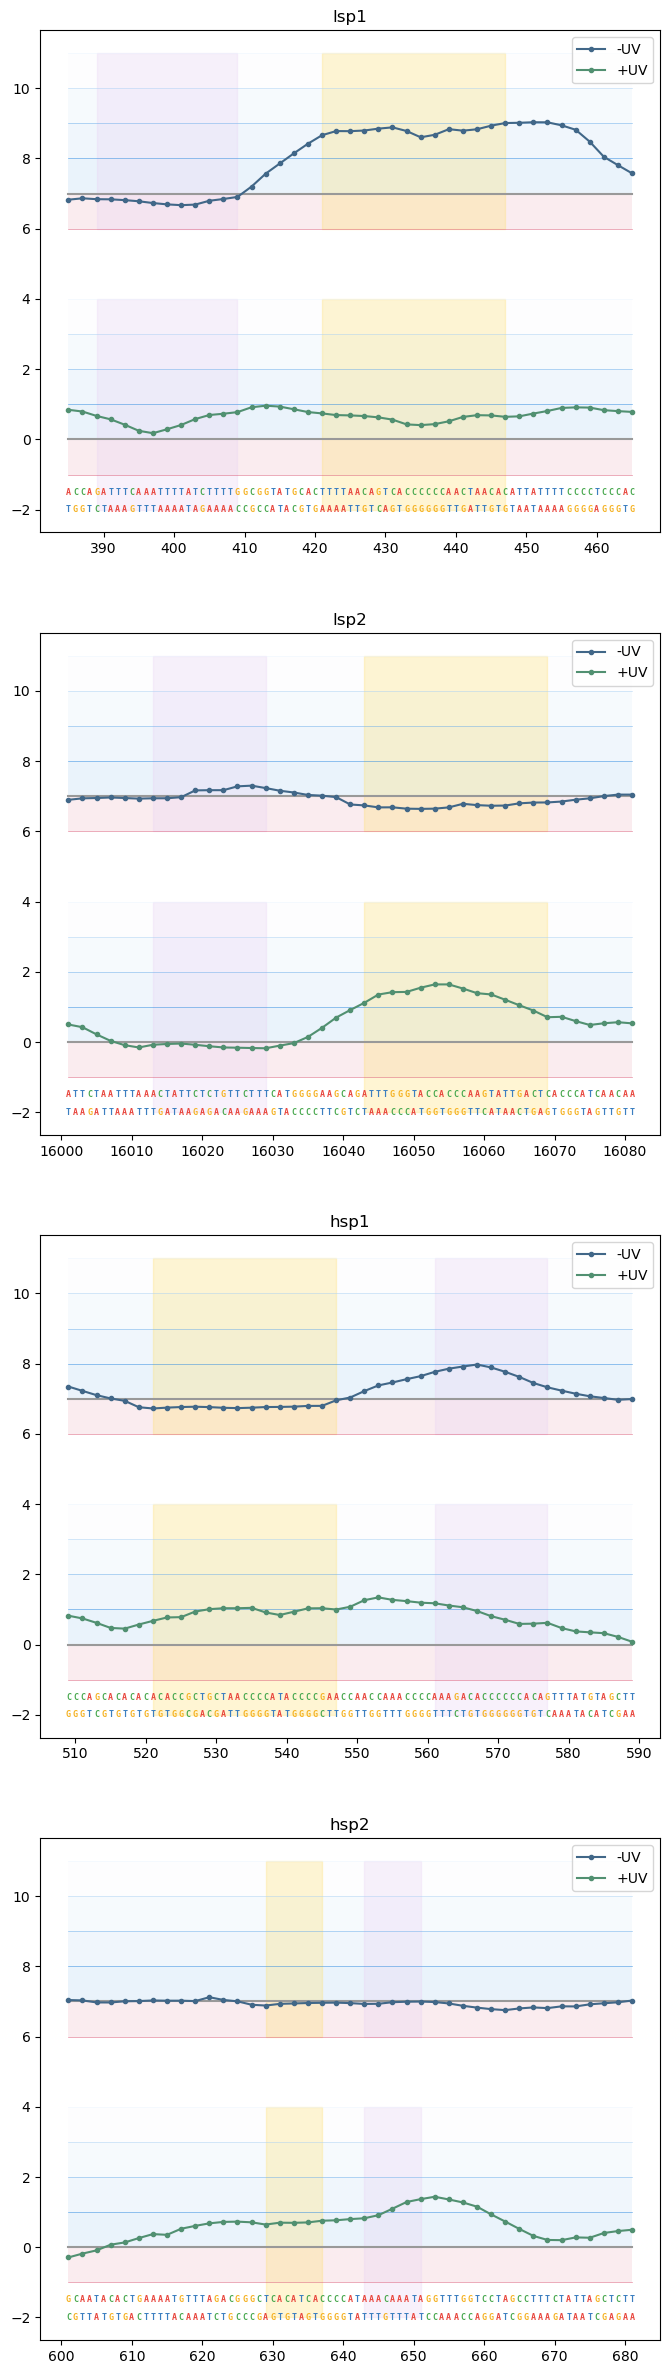

In [18]:
# Read in genome fasta for sequence
from Bio import SeqIO
mito_seq = str(SeqIO.read("data/human_mito_genome.fasta", "fasta").seq)

breakout_sep(c30_f, c30_r, uv30_f, uv30_r, "30_nM", mito_seq, window=11, total_length=41, offset=7)

# G-N10-G
- Figure 3 figure supplement 5

In [19]:
# find a g10g in the sequence
def g_ten_g(seq):
    g_seq = []
    c_seq = []
    for i, nuc in enumerate(seq):
        if nuc == "G":
            g_seq.append(i)

        if nuc == "C":
            c_seq.append(i)
    
    for g in g_seq:
        if len(seq) < g + 12:
            continue
        
        if seq[g:g+12].endswith("G"):
            return True

    for c in c_seq:
        if len(seq) < c + 12:
            continue
        
        if seq[c:c+12].endswith("C"):
            return True

    return False

# find the location from 5' where the g10g occurs
def g_ten_g_start(seq):
    g_seq = []
    c_seq = []
    for i, nuc in enumerate(seq):
        if nuc == "G":
            g_seq.append(i)

        if nuc == "C":
            c_seq.append(i)
    
    for g in g_seq:
        if len(seq) < g + 12:
            continue
        
        if seq[g:g+12].endswith("G"):
            return g

    for c in c_seq:
        if len(seq) < c + 12:
            continue
        
        if seq[c:c+12].endswith("C"):
            return c

    return -1

# count the number of g10gs in a sequence
def g_ten_g_count(seq):
    g_seq = []
    c_seq = []
    for i, nuc in enumerate(seq):
        if nuc == "G":
            g_seq.append(i)

        if nuc == "C":
            c_seq.append(i)
    
    count = 0
    for g in g_seq:
        if len(seq) < g + 12:
            continue
        
        if seq[g:g+12].endswith("G"):
            count += 1

    for c in c_seq:
        if len(seq) < c + 12:
            continue
        
        if seq[c:c+12].endswith("C"):
            count += 1

    return count

# find all sequences in a list of sequences that contain a g10g
def get_g10gs(seq_list):
    g_ten_g_list = []
    for i, seq in enumerate(seq_list):
        if g_ten_g(seq):
            g_ten_g_list.append(i)
    print(f"Number with g 10n g motif: {len(g_ten_g_list)}")

    return g_ten_g_list

# count sequences in a list of sequences that contain a g10g
def get_g10gs_count(seq_list):
    g_ten_g_list = []
    for seq in seq_list:
        g_ten_g_list.append(g_ten_g_count(seq))

    return g_ten_g_list

In [20]:
# run each function on each sequence, attempt to append results
# in the case of chip controls, there is no sequence, so append -1 for count/start loc, None for presence

# use variable seq only
end = 33

# use variable seq + first 11 of primer
# end = 45

counts = []
starts = []
g10gs = []

for seq in a["sequence"].to_list():
    try:
        counts.append(g_ten_g_count(seq[:end]))
    except TypeError:
        counts.append(-1)
    
    try:
        starts.append(g_ten_g_start(seq[:end]))
    except TypeError:
        starts.append(-1)
    
    try:
        g10gs.append(g_ten_g(seq[:end]))
    except TypeError:
        g10gs.append(None)

a["g10g_count"] = counts
a["g10g_start"] = starts
a["g10g"] = g10gs
a.head()

,name,condition,raw_mean,raw_median,raw_std,raw_std_percent,raw_sem,raw_sem_percent,raw_variance_coefficient,raw_mean_z,...,mid_coord,tt,tc,ct,cc,at,gc,g10g_count,g10g_start,g10g
0,ATP6_100_o1,ctrl_30,6678.1,6090.5,1143.436385,18.774097,361.586334,5.936891,0.171222,4.173026,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
1,ATP6_100_o1,uv_30,20787.1,22154.0,4584.957711,20.695846,1449.890934,6.544601,0.220567,0.136003,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
2,ATP6_100_o1,ctrl_300,8862.1,9808.0,2534.278265,25.838889,801.409154,8.170974,0.285968,4.390684,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
3,ATP6_100_o1,uv_300,34395.6,34876.0,2345.630273,6.725629,741.753421,2.126831,0.068196,2.174850,...,8727.0,4,5,7,3,58.82,41.18,0,-1,False
4,ATP6_100_o2,ctrl_30,11523.3,11679.0,1288.036840,11.028657,407.313012,3.487568,0.111777,13.522224,...,8727.0,4,6,7,3,58.82,41.18,0,-1,False


In [21]:
# Make dataframe of max value for each location
a["probe"] = [str(name).replace("_o1", "").replace("_o2", "").replace("_C", "") for name in a["name"]]
a_max = a[a["start_coord"] > 0].groupby(["probe", "condition"])[["norm_median_z", "g10g"]].max().reset_index()

### Figure 3 figure supplement 5 - Max median z score +/- g-n10-g motif for mitochondrial sequences

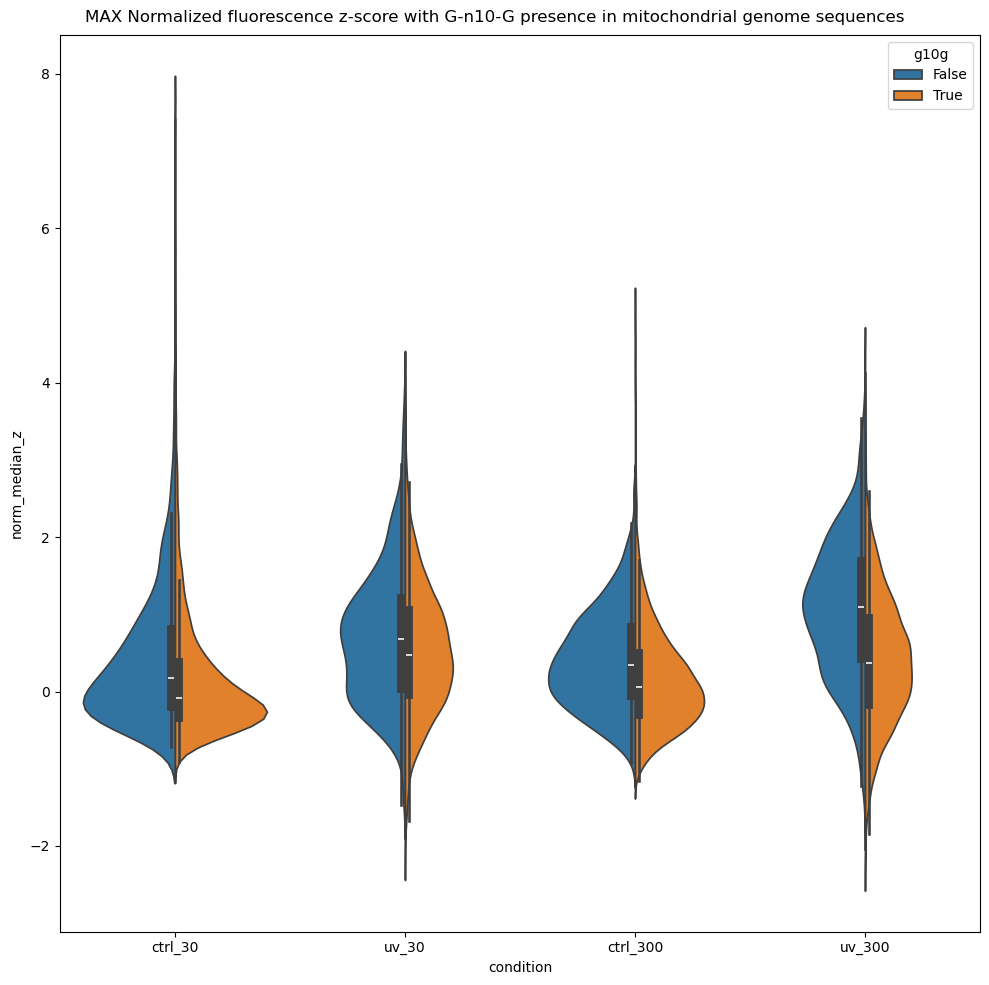

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sns.violinplot(data=a_max, x="condition", y="norm_median_z", hue="g10g", split=True, order=["ctrl_30", "uv_30", "ctrl_300", "uv_300"])
fig.suptitle("MAX Normalized fluorescence z-score with G-n10-G presence in mitochondrial genome sequences")
plt.tight_layout()
# plt.savefig("mito_g10g_max_violin.svg")
plt.show()

In [23]:
metric = "norm_median_z"
# metric = "norm_median"

c30ng = sorted(a_max.loc[(a_max["condition"] == "ctrl_30") & (a_max["g10g"] == False), metric].to_numpy())
c30g = sorted(a_max.loc[(a_max["condition"] == "ctrl_30") & (a_max["g10g"] == True), metric].to_numpy())

c300ng = sorted(a_max.loc[(a_max["condition"] == "ctrl_300") & (a_max["g10g"] == False), metric].to_numpy())
c300g = sorted(a_max.loc[(a_max["condition"] == "ctrl_300") & (a_max["g10g"] == True), metric].to_numpy())

uv30ng = sorted(a_max.loc[(a_max["condition"] == "uv_30") & (a_max["g10g"] == False), metric].to_numpy())
uv30g = sorted(a_max.loc[(a_max["condition"] == "uv_30") & (a_max["g10g"] == True), metric].to_numpy())

uv300ng = sorted(a_max.loc[(a_max["condition"] == "uv_300") & (a_max["g10g"] == False), metric].to_numpy())
uv300g = sorted(a_max.loc[(a_max["condition"] == "uv_300") & (a_max["g10g"] == True), metric].to_numpy())

print("Kolmogorov Smirnov")
print(f"c30\tp-value: {np.round(stats.kstest(c30ng, c30g, alternative='greater').pvalue, 3)}, stat: {np.round(stats.kstest(c30ng, c30g, alternative='greater').statistic, 4)}")
print(f"c300\tp-value: {np.round(stats.kstest(c300ng, c300g, alternative='greater').pvalue, 3)}, stat: {np.round(stats.kstest(c300ng, c300g, alternative='greater').statistic, 4)}")
print(f"uv30\tp-value: {np.round(stats.kstest(uv30ng, uv30g, alternative='greater').pvalue, 3)}, stat: {np.round(stats.kstest(uv30ng, uv30g, alternative='greater').statistic, 4)}")
print(f"uv300\tp-value: {np.round(stats.kstest(uv300ng, uv300g, alternative='greater').pvalue, 3)}, stat: {np.round(stats.kstest(uv300ng, uv300g, alternative='greater').statistic, 4)}")

Kolmogorov Smirnov
c30	p-value: 0.999, stat: 0.0007
c300	p-value: 0.872, stat: 0.0089
uv30	p-value: 1.0, stat: 0.0003
uv300	p-value: 1.0, stat: 0.0


/Users/satusky/anaconda3/envs/tfam-uv-pbm/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)


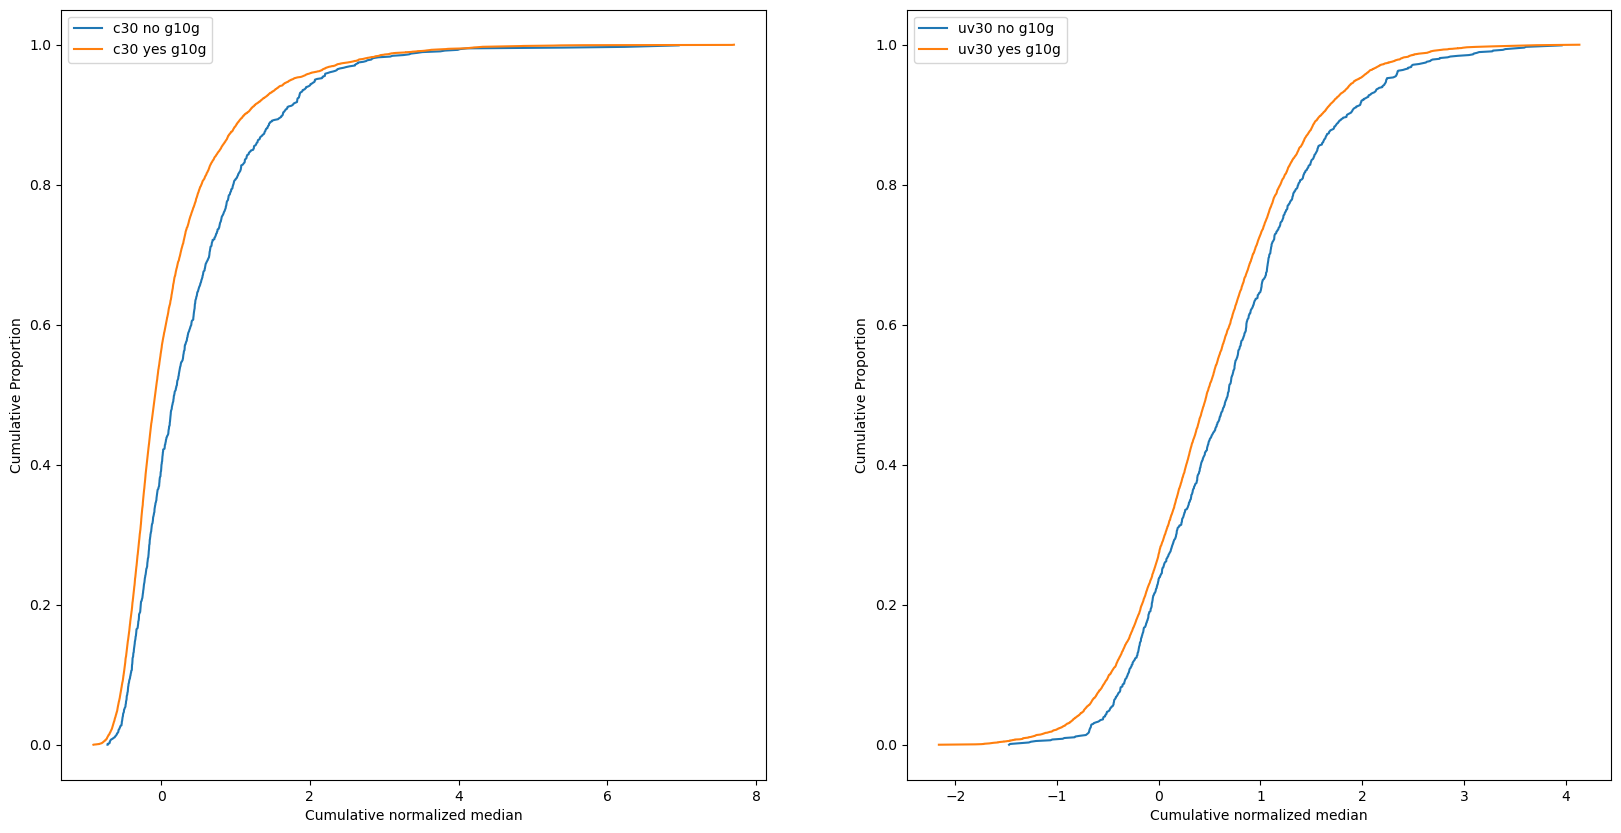

In [24]:
# Cumulative density function plot
def proportions(data):
    return 1. * np.arange(len(data)) / (len(data))

fig, axs = plt.subplots(1, 2, figsize=(20,10))
axs[0].plot(c30ng, proportions(c30ng), label="c30 no g10g")
axs[0].plot(c30g, proportions(c30g), label="c30 yes g10g")
axs[0].set(xlabel="Cumulative normalized median", ylabel="Cumulative Proportion")
axs[0].legend()

axs[1].plot(uv30ng, proportions(uv30ng), label="uv30 no g10g")
axs[1].plot(uv30g, proportions(uv30g), label="uv30 yes g10g")
axs[1].set(xlabel="Cumulative normalized median", ylabel="Cumulative Proportion")
axs[1].legend()

plt.show()

# Distributions
- Figure 3 figure supplement 4
- Figure 3 figure supplement 9

In [25]:
# Make a dataframe using max z score from o1/o2
window = 11

max_df = pd.DataFrame()
max_df["mid_coord"] = c30_f["mid_coord"].astype(int).to_list()[5:-5]
max_df["name"] = [c30_f[c30_f["mid_coord"] == i].index.to_list()[0] for i in max_df["mid_coord"]]
max_df["sequence"] = [c30_f.loc[name, "sequence"] for name in max_df["name"]]
max_df = max_df.set_index("name")

# Get smoothed maxes
max_df["c30_median_z"] = [
        max(o1, o2) for o1, o2 in zip(
            moving_average(c30_f["norm_median_z"].to_numpy(), n=window),
            moving_average(c30_r["norm_median_z"].to_numpy(), n=window)
        )
    ]
max_df["uv30_median_z"] = [
    max(o1, o2) for o1, o2 in zip(
            moving_average(uv30_f["norm_median_z"].to_numpy(), n=window),
            moving_average(uv30_r["norm_median_z"].to_numpy(), n=window)
        )
    ]
max_df["c300_median_z"] = [
    max(o1, o2) for o1, o2 in zip(
            moving_average(c300_f["norm_median_z"].to_numpy(), n=window),
            moving_average(c300_r["norm_median_z"].to_numpy(), n=window)
        )
    ]
max_df["uv300_median_z"] = [
    max(o1, o2) for o1, o2 in zip(
            moving_average(uv300_f["norm_median_z"].to_numpy(), n=window),
            moving_average(uv300_r["norm_median_z"].to_numpy(), n=window)
        )
    ]

#  Difference between +/- UV
max_df["diff_30"] = [uv - ctrl for ctrl, uv in zip(max_df["c30_median_z"].to_list(), max_df["uv30_median_z"].to_list())]
max_df["diff_300"] = [uv - ctrl for ctrl, uv in zip(max_df["c300_median_z"].to_list(), max_df["uv300_median_z"].to_list())]
max_df = max_df.reset_index()
max_df["name"] = [name.replace("_o1", "") for name in max_df["name"]]
max_df = max_df.set_index("name")
#max_df.to_csv("binders_ctrl_all_smooth.csv", index=True)
max_df.head()

,mid_coord,sequence,c30_median_z,uv30_median_z,c300_median_z,uv300_median_z,diff_30,diff_300
name,,,,,,,,
D-loop_559,12,CGATGGATCACAGGTCTATCACCCTATTAACCACATATGCGTGCGT...,-0.445084,0.631320,-0.519946,0.523867,1.076404,1.043813
D-loop_560,14,ATGGATCACAGGTCTATCACCCTATTAACCACTCATATGCGTGCGT...,-0.441178,0.697442,-0.475826,0.585907,1.138620,1.061733
D-loop_561,16,GGATCACAGGTCTATCACCCTATTAACCACTCACATATGCGTGCGT...,-0.417794,0.764306,-0.384798,0.666797,1.182101,1.051595
D-loop_1,17,GATCACAGGTCTATCACCCTATTAACCACTCACCATATGCGTGCGT...,-0.364120,0.830624,-0.300572,0.704164,1.194744,1.004736
D-loop_2,19,TCACAGGTCTATCACCCTATTAACCACTCACGGCATATGCGTGCGT...,-0.337662,0.819186,-0.254086,0.666738,1.156848,0.920824


### Figure 3 figure supplement 4 - median z scores 30 nM TFAM -UV vs 300 nM TFAM -UV

PearsonRResult(statistic=np.float64(0.8653580253674152), pvalue=np.float64(0.0))


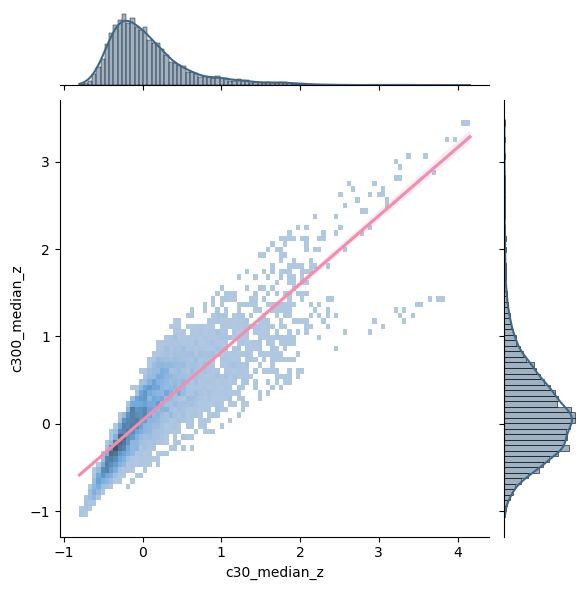

In [26]:
g = sns.jointplot(max_df, x="c30_median_z", y="c300_median_z", kind="hist", color="#416788", marginal_kws={"kde": True})
sns.regplot(max_df, x="c30_median_z", y="c300_median_z", ax=g.ax_joint, scatter=False, color="#F48DAD")
#g.ax_joint.set(xlim=[-1.5,4.5], ylim=[-1.5,4.5])
print(stats.pearsonr(max_df["c30_median_z"], max_df["c300_median_z"]))
# plt.savefig("c30_v_c300.svg")
plt.show()

### Figure 3 figure supplement 9 - z score before UV exposure vs change in z score after UV exposure

PearsonRResult(statistic=np.float64(-0.5264907242190602), pvalue=np.float64(0.0))


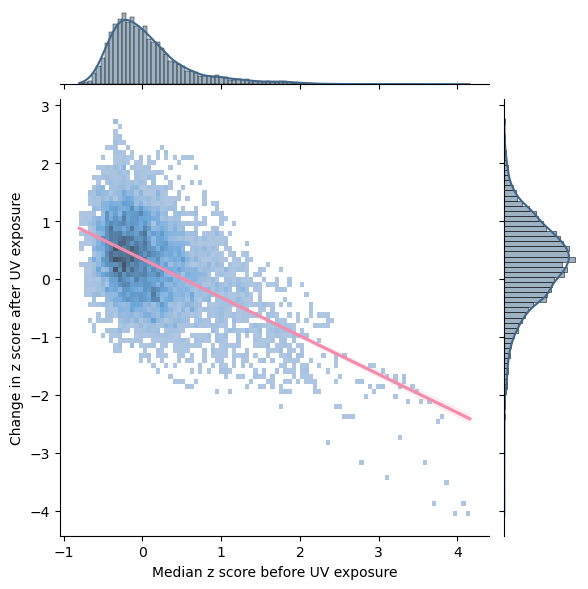

In [27]:
g = sns.jointplot(max_df, x="c30_median_z", y="diff_30", kind="hist", color="#416788", marginal_kws={"kde": True})
sns.regplot(max_df, x="c30_median_z", y="diff_30", ax=g.ax_joint, scatter=False, color="#F48DAD")
print(stats.pearsonr(max_df["c30_median_z"], max_df["diff_30"]))
plt.xlabel("Median z score before UV exposure")
plt.ylabel("Change in z score after UV exposure")
# plt.savefig("uv_diff_correlation.svg")
plt.show()

In [28]:
tops = max_df.sort_values(by="c30_median_z", ascending=False).iloc[:415]
bottoms = max_df.sort_values(by="c30_median_z", ascending=False).iloc[-415:]

### Figure 3 figure supplement 9a  - Distribution of top 5% of binders

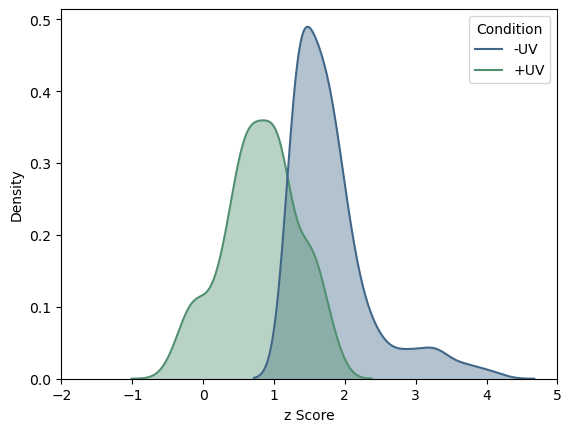

In [29]:
# Melt it so we can get a KDE plot
mtops30 = tops.rename(columns={"c30_median_z": "-UV", "uv30_median_z": "+UV"}).melt(id_vars="mid_coord", value_vars=["-UV", "+UV"], var_name="Condition", value_name="z Score")

palette = sns.set_palette(sns.color_palette(["#416788", "#519071"]))
ax = sns.kdeplot(mtops30, x="z Score", hue="Condition", palette=palette)
uv_kde_x, uv_kde_y = ax.lines[0].get_data()
c_kde_x, c_kde_y = ax.lines[1].get_data()
ax.fill_between(c_kde_x, c_kde_y, interpolate=True, color="#416788", linewidth=0, alpha=0.4)
ax.fill_between(uv_kde_x, uv_kde_y, interpolate=True, color="#519071", linewidth=0, alpha=0.4)
ax.set(xlim=[-2, 5])
# plt.savefig("top_5%.svg")
plt.show()

### Figure 3 figure supplement 9b - Distribution of bottom 5% of binders

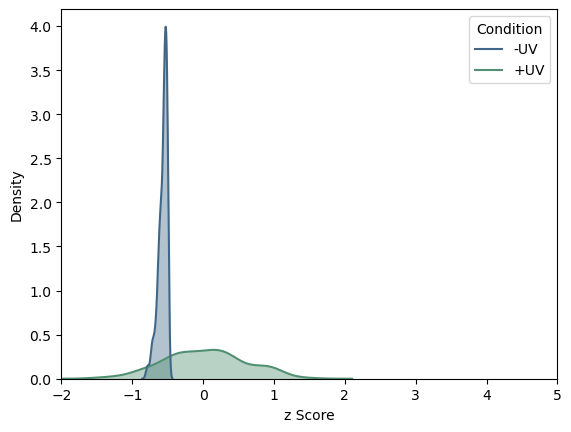

In [30]:
mbots30 = bottoms.rename(columns={"c30_median_z": "-UV", "uv30_median_z": "+UV"}).melt(id_vars="mid_coord", value_vars=["-UV", "+UV"], var_name="Condition", value_name="z Score")

palette = sns.set_palette(sns.color_palette(["#416788", "#519071"]))
ax = sns.kdeplot(mbots30, x="z Score", hue="Condition", palette=palette)
uv_kde_x, uv_kde_y = ax.lines[0].get_data()
c_kde_x, c_kde_y = ax.lines[1].get_data()
ax.fill_between(c_kde_x, c_kde_y, interpolate=True, color="#416788", linewidth=0, alpha=0.4)
ax.fill_between(uv_kde_x, uv_kde_y, interpolate=True, color="#519071", linewidth=0, alpha=0.4)
#ax.set(xlim=[-2,5], ylim=[0,4.5])
ax.set(xlim=[-2, 5])
# plt.savefig("bottom_5%.svg")
plt.show()